<a href="https://colab.research.google.com/github/RBOM12/tpValorisationdeladonn-es/blob/main/TP4_BROCHET_Valorisation_de_la_donn%C3%A9es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP 4 Valorisation de la données

Apprentissage supervisé (régression) et Intelligence Artificielle eXplicable (LIME & SHAP).

## Apprentissage supervisé : régression

Contrairement à la classification, où l'on prédit des valeurs discrètes (des classes), la **régression** prédit des valeurs **continues**. Ici, ces valeurs continues sont des **prix de maisons** (colonne `price`).

In [1]:
# Imports pour la régression et l'IA explicable
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error

> **1.** Charger le jeu de données *housing* (fichier `Housing.csv`). Les valeurs à prédire sont dans la colonne `price` : les stocker dans un vecteur `y`. Le reste des données est stocké dans une matrice `X`. La première ligne du fichier contient les noms des colonnes. Combien d'attributs (variables) et combien de données contient le jeu de données ?

In [2]:
# 1. Chargement du jeu de données housing
# La première ligne du CSV contient les noms de colonnes (comportement par défaut de read_csv).
df = pd.read_csv("Housing.csv")

# La cible à prédire est la colonne 'price' -> vecteur y
y = df["price"].values
# Le reste des données constitue la matrice X
X = df.drop(columns="price")

# Noms des attributs (utiles plus tard pour LIME et SHAP)
feature_names = list(X.columns)

print(f"Nombre de données (instances) : {X.shape[0]}")
print(f"Nombre d'attributs (variables) : {X.shape[1]}")
print(f"\nAttributs : {feature_names}")
df.head()

Nombre de données (instances) : 545
Nombre d'attributs (variables) : 12

Attributs : ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Le jeu de données contient **545 données (instances)** et **12 attributs** (la 13ᵉ colonne `price` étant la cible `y`, elle ne fait pas partie de `X`).

Parmi ces 12 attributs, certains sont **numériques** (`area`, `bedrooms`, `bathrooms`, `stories`, `parking`) et d'autres sont **catégoriels** (`mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea`, `furnishingstatus`).

> **2.** Le jeu de données contient des variables **catégorielles**, or nous ne travaillons qu'avec des nombres. Transformer ces variables catégorielles en nombres à l'aide d'un objet de la classe `OrdinalEncoder` de `sklearn.preprocessing`. Pour `furnishingstatus` : 0 pour *unfurnished*, 1 pour *semi-furnished*, 2 pour *furnished*. Pour les attributs booléens : *yes* devient 1 et *no* devient 0.

In [3]:
# 2. Transformation des variables catégorielles en nombres avec OrdinalEncoder
# On choisit la 1re approche (un nombre par catégorie), et NON le OneHotEncoding.
colonnes_cat = ["mainroad", "guestroom", "basement", "hotwaterheating",
                "airconditioning", "prefarea", "furnishingstatus"]

# On impose explicitement l'ordre des catégories pour respecter la consigne :
#   - booléens : no -> 0, yes -> 1
#   - furnishingstatus : unfurnished -> 0, semi-furnished -> 1, furnished -> 2
categories = [["no", "yes"]] * 6 + [["unfurnished", "semi-furnished", "furnished"]]

encoder = OrdinalEncoder(categories=categories)
X = X.copy()
X[colonnes_cat] = encoder.fit_transform(X[colonnes_cat])

# On convertit X en matrice numpy de réels (toutes les colonnes sont désormais numériques)
X = X.values.astype(float)

print("X est maintenant entièrement numérique, de forme :", X.shape)
print("Exemple (5 premières lignes) :")
print(np.round(X[:5], 2))

X est maintenant entièrement numérique, de forme : (545, 12)
Exemple (5 premières lignes) :
[[7.42e+03 4.00e+00 2.00e+00 3.00e+00 1.00e+00 0.00e+00 0.00e+00 0.00e+00
  1.00e+00 2.00e+00 1.00e+00 2.00e+00]
 [8.96e+03 4.00e+00 4.00e+00 4.00e+00 1.00e+00 0.00e+00 0.00e+00 0.00e+00
  1.00e+00 3.00e+00 0.00e+00 2.00e+00]
 [9.96e+03 3.00e+00 2.00e+00 2.00e+00 1.00e+00 0.00e+00 1.00e+00 0.00e+00
  0.00e+00 2.00e+00 1.00e+00 1.00e+00]
 [7.50e+03 4.00e+00 2.00e+00 2.00e+00 1.00e+00 0.00e+00 1.00e+00 0.00e+00
  1.00e+00 3.00e+00 1.00e+00 2.00e+00]
 [7.42e+03 4.00e+00 1.00e+00 2.00e+00 1.00e+00 1.00e+00 1.00e+00 0.00e+00
  1.00e+00 2.00e+00 0.00e+00 2.00e+00]]


Toutes les variables catégorielles sont désormais encodées en nombres. On a utilisé la **première approche** (un entier par catégorie) demandée par l'énoncé, et non le *OneHotEncoding*.

Le paramètre `categories` de l'`OrdinalEncoder` permet d'**imposer l'ordre** : sans lui, `furnishingstatus` aurait été encodé par ordre alphabétique (*furnished*=0), ce qui ne correspond pas à la consigne (*unfurnished*=0, *semi-furnished*=1, *furnished*=2). Le nombre de dimensions reste inchangé (**12**), contrairement au OneHotEncoding qui aurait ajouté des colonnes.

> **3.** Séparer le jeu de données en un jeu d'entraînement (70 %) et un jeu de test (30 %) avec `train_test_split`, en fixant `random_state=42`. Stocker les ensembles dans `X_train`, `y_train`, `X_test`, `y_test`.

In [4]:
# 3. Séparation en jeu d'entraînement (70%) et jeu de test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("X_train :", X_train.shape, "|  y_train :", y_train.shape)
print("X_test  :", X_test.shape, "|  y_test  :", y_test.shape)

X_train : (381, 12) |  y_train : (381,)
X_test  : (164, 12) |  y_test  : (164,)


> **4.** À quoi sert la normalisation ? Normaliser le jeu de données.

In [5]:
# 4. Normalisation des attributs avec le StandardScaler
# On entraîne (fit) le scaler uniquement sur X_train pour ne pas laisser fuiter
# d'information du jeu de test, puis on applique la transformation séparément.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Avant normalisation - moyennes des attributs (X_train) :")
print(np.round(X_train.mean(axis=0), 1))
print("\nAprès normalisation - moyennes (≈ 0) et écarts-types (≈ 1) :")
print("moyennes  :", np.round(X_train_scaled.mean(axis=0), 3))
print("écarts-types :", np.round(X_train_scaled.std(axis=0), 3))

Avant normalisation - moyennes des attributs (X_train) :
[5.1284e+03 3.0000e+00 1.3000e+00 1.8000e+00 9.0000e-01 2.0000e-01
 4.0000e-01 1.0000e-01 3.0000e-01 7.0000e-01 2.0000e-01 1.0000e+00]

Après normalisation - moyennes (≈ 0) et écarts-types (≈ 1) :
moyennes  : [-0.  0.  0. -0. -0.  0.  0.  0.  0. -0. -0.  0.]
écarts-types : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**À quoi sert la normalisation ?** Les attributs ont des **échelles très différentes** : `area` se compte en milliers (de pieds carrés) tandis que `bedrooms` ou `parking` valent quelques unités. Sans normalisation, les attributs de grande amplitude domineraient le calcul des distances, et un SVM (qui s'appuie sur des distances via son noyau) serait biaisé en leur faveur.

La normalisation **ramène tous les attributs à la même échelle** (moyenne 0, écart-type 1 avec le `StandardScaler`), ce qui permet à chaque attribut de contribuer équitablement et accélère/améliore l'entraînement. Comme en TP3, on `fit` le scaler **uniquement sur `X_train`** puis on l'applique séparément à `X_train` et `X_test`, afin que le jeu de test reste inconnu du modèle.

> **5.** Entraîner un régresseur SVM avec la classe `SVR` de `sklearn.svm` (noyau `rbf`), en utilisant `y_train` et la version normalisée de `X_train`.

In [6]:
# 5. Entraînement d'un régresseur SVM (SVR, noyau RBF)
regressor = SVR(kernel="rbf")
regressor.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


On entraîne le `SVR` avec le noyau `rbf` sur `X_train_scaled` (attributs normalisés) et `y_train` (les prix). La méthode `fit` ajuste le modèle de régression.

> **6.** Calculer les prédictions de chaque instance du jeu de test (normalisé) avec `predict`. Les stocker dans `y_pred`. `y_pred` contient les prix prédits, `y_test` les vrais prix.

In [7]:
# 6. Prédictions sur le jeu de test normalisé
y_pred = regressor.predict(X_test_scaled)

# Comparaison des 5 premières prédictions avec les vraies valeurs
print("Prédiction  ->  Vrai prix")
for p, v in zip(y_pred[:5], y_test[:5]):
    print(f"{p:12,.0f}  ->  {v:12,.0f}")

Prédiction  ->  Vrai prix
   4,382,001  ->     4,060,000
   4,382,023  ->     6,650,000
   4,381,960  ->     3,710,000
   4,381,993  ->     6,440,000
   4,381,977  ->     2,800,000


`y_pred` contient les prix **prédits** par le modèle pour chaque maison du jeu de test, tandis que `y_test` contient les **vrais** prix. On remarque que les prédictions sont toutes très proches les unes des autres (autour de la moyenne des prix), ce qui est un premier indice de la difficulté du modèle à capturer les variations de prix — on le confirme avec les métriques d'erreur à la question suivante.

> **7.** Évaluer le modèle en calculant l'**erreur quadratique moyenne** (*mean squared error*) et l'**erreur absolue moyenne** (*mean absolute error*) avec `mean_squared_error` et `mean_absolute_error` de `sklearn.metrics`. Plus ces erreurs sont faibles, meilleur est le modèle.

In [8]:
# 7. Évaluation : erreur quadratique moyenne (MSE) et erreur absolue moyenne (MAE)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)   # racine de la MSE, dans la même unité que les prix

print(f"MSE  (erreur quadratique moyenne) : {mse:,.0f}")
print(f"RMSE (racine de la MSE)           : {rmse:,.0f}")
print(f"MAE  (erreur absolue moyenne)     : {mae:,.0f}")
print(f"\nPour comparaison, prix moyen des maisons : {y.mean():,.0f}")
print(f"MAE en % du prix moyen : {100 * mae / y.mean():.1f} %")

MSE  (erreur quadratique moyenne) : 4,462,179,323,913
RMSE (racine de la MSE)           : 2,112,387
MAE  (erreur absolue moyenne)     : 1,578,104

Pour comparaison, prix moyen des maisons : 4,766,729
MAE en % du prix moyen : 33.1 %


Les erreurs sont **élevées** : la MAE vaut environ **1 580 000**, soit près de **33 %** du prix moyen (≈ 4 770 000). Contrairement à la précision et au rappel vus en classification, ici **plus l'erreur est faible, meilleur est le modèle** — et ces valeurs montrent que le modèle est **médiocre**.

L'explication tient au `SVR` utilisé avec ses **hyperparamètres par défaut** (`C=1.0`, `epsilon=0.1`) : la cible `price` n'étant pas normalisée et prenant de très grandes valeurs (millions), le coût de régularisation par défaut est largement insuffisant. Le modèle prédit alors quasiment la **valeur moyenne** pour toutes les maisons (cf. question 6). On pourrait l'améliorer en augmentant fortement `C`, en ajustant `epsilon`/`gamma` (via une recherche d'hyperparamètres), voire en normalisant aussi `y` — mais l'énoncé nous demande la configuration de base, que nous conservons ici.

> **8.** Expliquer quelques instances avec **LIME** et **SHAP**.

Comme en TP3, on installe les deux bibliothèques puis on instancie un *explainer* pour chacune, cette fois en mode **régression**.

### LIME

In [9]:
# Installation de LIME dans l'environnement TP_VD
!pip install lime


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# Instanciation de l'explainer LIME en mode régression
from lime.lime_tabular import LimeTabularExplainer

# mode="regression" car on prédit une valeur continue (le prix) et non une classe.
# On fournit les données d'entraînement normalisées et les noms des attributs.
lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=feature_names,
    mode="regression",
    random_state=42,
)

On choisit une instance du jeu de test et on l'explique avec `explain_instance`. Pour une régression, l'explication indique comment chaque attribut **augmente** ou **diminue** le prix prédit par rapport à la moyenne.

In [11]:
# Explication LIME de l'instance d'indice 10 du jeu de test
idx = 10
prix_predit = regressor.predict(X_test_scaled[idx].reshape(1, -1))[0]

print(f"Instance n°{idx}")
print(f"Prix prédit : {prix_predit:,.0f}")
print(f"Vrai prix   : {y_test[idx]:,.0f}")

explication = lime_explainer.explain_instance(
    X_test_scaled[idx],
    regressor.predict,
    num_features=12,
)

Instance n°10
Prix prédit : 4,382,019
Vrai prix   : 10,150,000


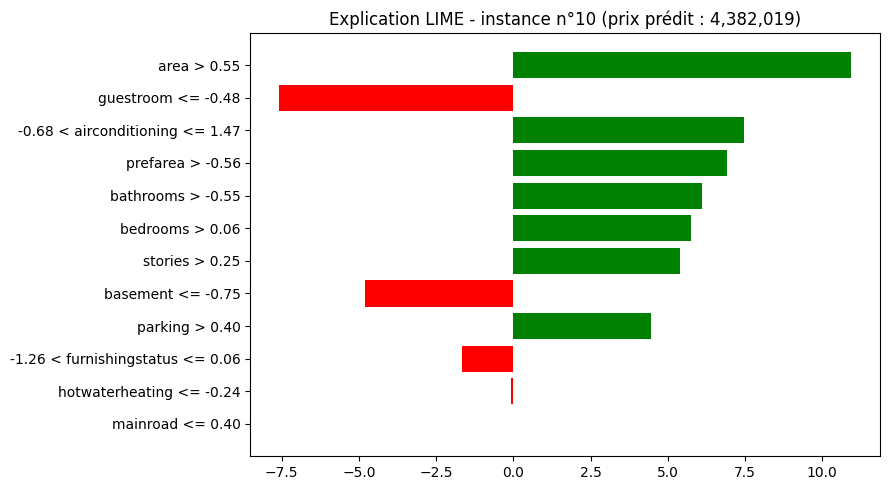

In [12]:
# Visualisation de l'explication LIME
fig = explication.as_pyplot_figure()
fig.set_size_inches(9, 5)
plt.title(f"Explication LIME - instance n°{idx} (prix prédit : {prix_predit:,.0f})")
plt.tight_layout()
plt.show()

**Que traduit l'explication ?** Chaque barre indique dans quelle mesure un attribut **pousse le prix prédit vers le haut** (barres positives, en vert) ou **vers le bas** (barres négatives, en rouge), par rapport à la prédiction moyenne.

Les attributs les plus déterminants sont `area` (la surface), `airconditioning`, `bathrooms` et `stories` : une surface élevée et la présence de climatisation tirent le prix vers le haut, ce qui est cohérent avec l'intuition du marché immobilier. À l'inverse, l'absence de certains équipements diminue le prix estimé.

### SHAP

In [13]:
# Installation de SHAP dans l'environnement TP_VD
!pip install shap


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
# Instanciation de l'explainer SHAP (classe Sampling) en régression
# La classe Sampling calcule des approximations des valeurs de Shapley.
import shap

shap_explainer = shap.explainers.Sampling(regressor.predict, X_train_scaled)

C:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
# Calcul des valeurs SHAP de l'instance d'indice 10 du jeu de test normalisé
shap_values = shap_explainer.shap_values(X_test_scaled[idx])

# En régression, shap_values est un simple vecteur (une valeur par attribut).
print("Forme des valeurs SHAP :", np.asarray(shap_values).shape, " (un coefficient par attribut)")
print(f"Valeur attendue (expected_value, ≈ prix moyen prédit) : {shap_explainer.expected_value:,.0f}\n")

# Affichage des valeurs SHAP triées par importance (valeur absolue)
ordre = np.argsort(np.abs(shap_values))[::-1]
print(f"Contributions SHAP pour l'instance n°{idx} :")
for i in ordre:
    print(f"   {shap_values[i]:+12,.0f}   {feature_names[i]}")

Forme des valeurs SHAP : (12,)  (un coefficient par attribut)
Valeur attendue (expected_value, ≈ prix moyen prédit) : 4,381,996

Contributions SHAP pour l'instance n°10 :
             +5   area
             +4   stories
             +4   airconditioning
             +3   bathrooms
             +3   prefarea
             +2   parking
             +2   bedrooms
             -1   basement
             +1   mainroad
             +1   furnishingstatus
             -0   guestroom
             +0   hotwaterheating


Chaque valeur SHAP indique la **contribution d'un attribut** à l'écart entre le prix prédit pour cette maison et le prix moyen prédit (`expected_value`). Une valeur **positive** augmente le prix estimé, une valeur **négative** le diminue. Les contributions sont **additives** : `expected_value` + somme des valeurs SHAP = prix prédit pour l'instance.

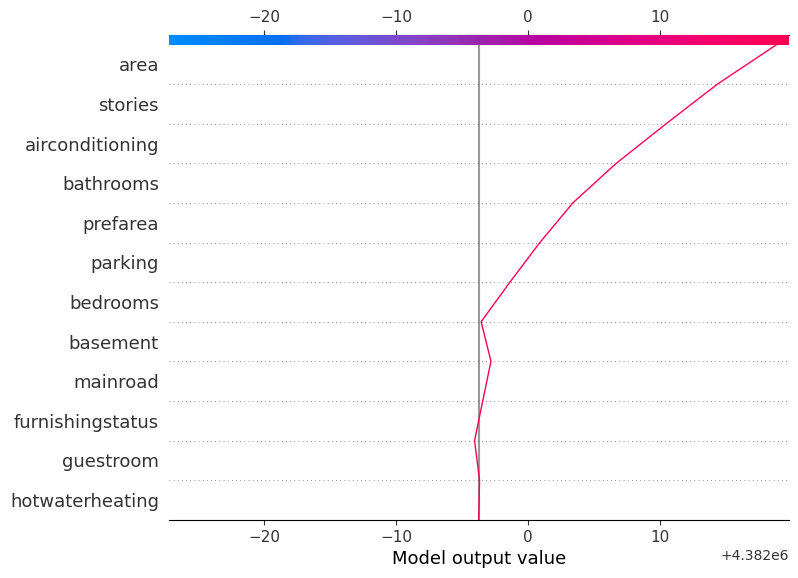

In [16]:
# Visualisation avec le decision plot
# Premier argument = prédiction moyenne (expected_value).
shap.plots.decision(
    shap_explainer.expected_value,
    shap_values,
    feature_names=feature_names,
)

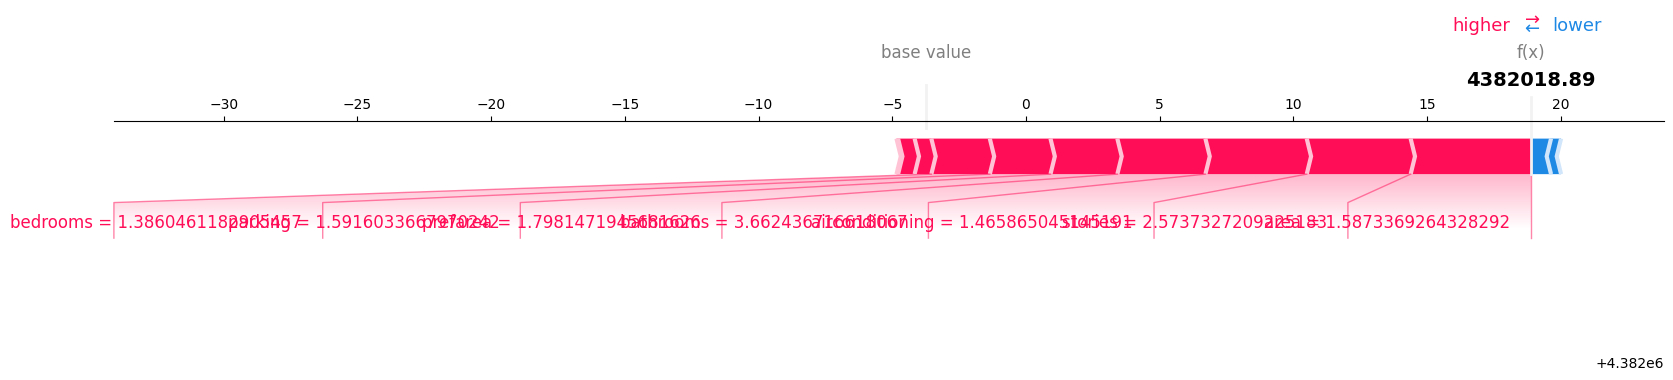

In [17]:
# Visualisation avec le force plot : il affiche en plus la valeur de chaque attribut
shap.plots.force(
    shap_explainer.expected_value,
    shap_values,
    features=X_test_scaled[idx],
    feature_names=feature_names,
    matplotlib=True,
)

Le *decision plot* part du prix moyen et empile les contributions attribut par attribut jusqu'au prix final. Le *force plot* montre les mêmes forces sur un axe horizontal et affiche **la valeur réelle de chaque attribut** à côté de sa contribution.

**Comparaison LIME / SHAP.** Les deux méthodes désignent les **mêmes attributs déterminants** (`area`, `airconditioning`, `bathrooms`, `stories`) avec des signes cohérents, ce qui renforce la confiance dans l'explication. LIME ajuste un modèle linéaire local autour de l'instance (poids relatifs, légère variabilité selon l'échantillonnage), tandis que SHAP repose sur les valeurs de Shapley dont les contributions sont **additives** et théoriquement plus fondées.

Enfin, on explique une **autre instance** de notre choix pour vérifier la cohérence des explications.

Instance n°88 (la plus chère du jeu de test)
Prix prédit : 4,382,027  |  Vrai prix : 13,300,000



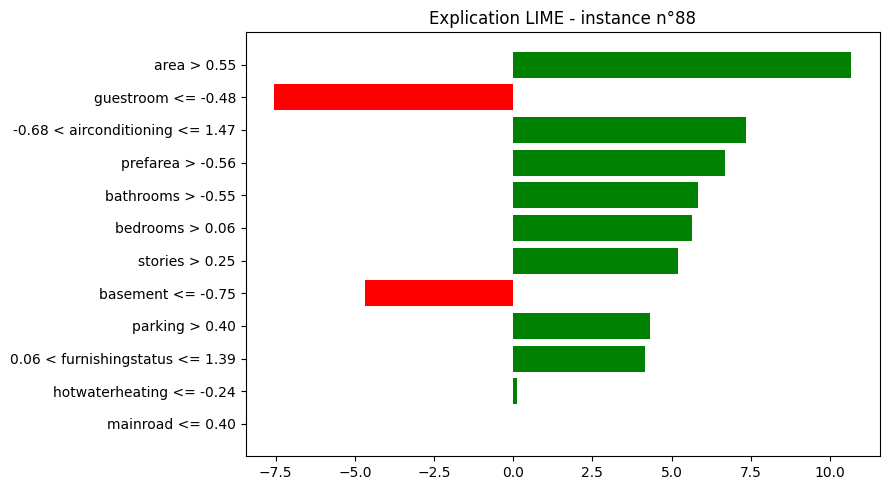

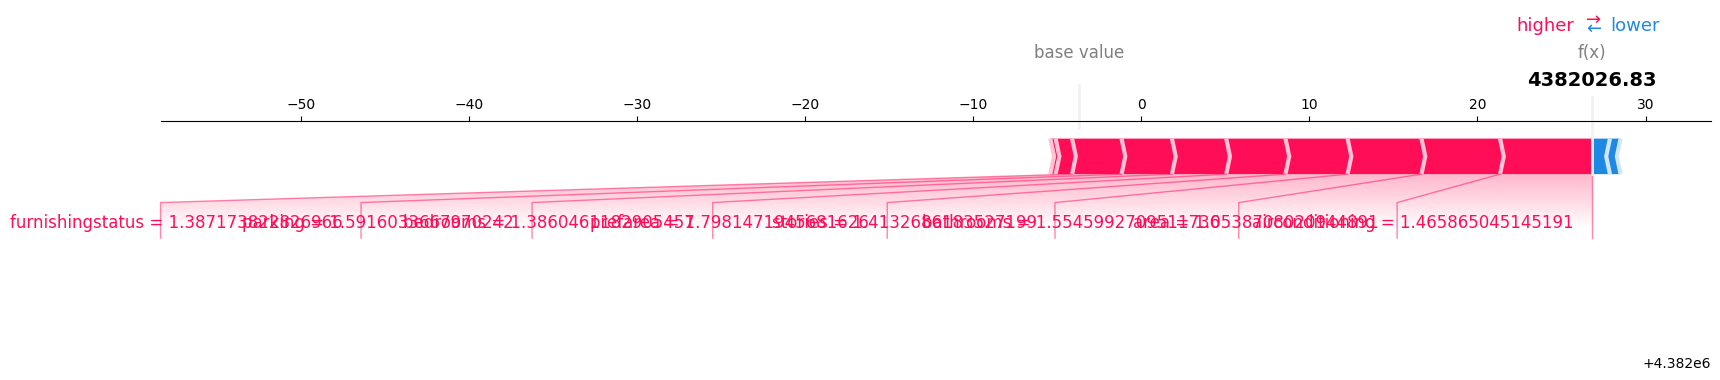

In [18]:
# Explication d'une autre instance (la maison la plus chère du jeu de test)
idx2 = int(np.argmax(y_test))
prix_predit2 = regressor.predict(X_test_scaled[idx2].reshape(1, -1))[0]
print(f"Instance n°{idx2} (la plus chère du jeu de test)")
print(f"Prix prédit : {prix_predit2:,.0f}  |  Vrai prix : {y_test[idx2]:,.0f}\n")

# LIME
exp2 = lime_explainer.explain_instance(X_test_scaled[idx2], regressor.predict, num_features=12)
fig = exp2.as_pyplot_figure()
fig.set_size_inches(9, 5)
plt.title(f"Explication LIME - instance n°{idx2}")
plt.tight_layout()
plt.show()

# SHAP
shap_values2 = shap_explainer.shap_values(X_test_scaled[idx2])
shap.plots.force(
    shap_explainer.expected_value, shap_values2,
    features=X_test_scaled[idx2], feature_names=feature_names, matplotlib=True,
)

Pour cette maison (la plus chère du jeu de test), LIME et SHAP s'accordent à nouveau : les attributs `area`, `airconditioning` et `bathrooms` ressortent comme les principaux moteurs du prix. On note toutefois que le prix prédit reste bien **en-dessous** du vrai prix : le modèle, qui prédit proche de la moyenne, **sous-estime fortement les maisons haut de gamme** — ce que l'analyse des erreurs (question 7) avait déjà révélé. L'IA explicable confirme ainsi, de façon visuelle et locale, le comportement global du modèle.